# Mini-Proyecto: Clasificación de noticias en español con BERT

> Caso propio basado en las técnicas de clasificación con Transformers y Hugging Face trabajadas en los notebooks del curso. Se cambia el conjunto de datos y el caso de estudio: aquí se clasifican noticias por tema, no reseñas ni toxicidad.

Consulta el [README del proyecto](README.md) para la descripción, instrucciones de ejecución y configuración experimental.

Este proyecto estudia si un modelo de lenguaje preentrenado en español puede clasificar artículos de noticias según las categorías provistas por el conjunto de datos.

**Pregunta de investigación:** ¿cómo se compara BERT, congelado o ajustado al corpus, con una línea base TF-IDF para clasificar noticias, y qué categorías se confunden con mayor frecuencia?

**Hipótesis:** adaptar todas las capas al corpus periodístico podría mejorar F1 macro frente a usar representaciones congeladas y el baseline clásico, aunque la ganancia podría no justificar el mayor costo de cómputo. Se comparan TF-IDF + Regresión Logística, BERT congelado, un clasificador no lineal y fine-tuning completo.

**Datos:** `hacktoberfest-corpus-es/colmbian_spanish_news`, un corpus público multifuente de noticias en español con categorías textuales. Tiene 76.151 registros y particiones `train`, `valid` y `test`. Se usan el titular y el cuerpo; `category` es la etiqueta objetivo.

**Comparación:** accuracy y F1 macro en el mismo test, métricas por categoría y revisión cualitativa de errores. Solo se limita el tamaño de entrenamiento por categoría; validación y prueba conservan sus particiones y distribuciones originales.

**Limitaciones:** las categorías reflejan la taxonomía del corpus y pueden contener ruido o solapamientos. La colección es multifuente, y el resultado en estas particiones no demuestra generalización a otros medios o periodos. El corpus está publicado bajo CC BY 2.0: conserva esta atribución al reutilizarlo.

Al ejecutar el notebook, completa la discusión con métricas y observaciones reales; aquí no se presuponen resultados.

#### Referencias
- Dataset y licencia: https://huggingface.co/datasets/hacktoberfest-corpus-es/colmbian_spanish_news
- BERT: https://huggingface.co/dccuchile/bert-base-spanish-wwm-cased
- Notebook guía del curso: `Sesion3/1-text-classification-with-hf.ipynb`
- Hugging Face Datasets: https://huggingface.co/docs/datasets

In [1]:
!pip install -q torch torchinfo transformers evaluate requests pyarrow datasets scikit-learn matplotlib
print('Dependencias listas')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 1.7 MB/s eta 0:00:00
Dependencias listas


## Detección del entorno

In [2]:
# Ejecutar solo una vez. En Colab, reiniciar el kernel después si es necesario.
# !pip install torch torchinfo transformers evaluate datasets

import pkg_resources, warnings
warnings.filterwarnings('ignore')

installed_packages = [p.key for p in pkg_resources.working_set]
IN_COLAB = 'google-colab' in installed_packages
print(f"Ejecutando en Colab: {IN_COLAB}")

/tmp/ipykernel_628/2839250735.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources, warnings


Ejecutando en Colab: True


## Carga del corpus de noticias

Usamos `hacktoberfest-corpus-es/colmbian_spanish_news`, un dataset público de Hugging Face que no requiere token. Contiene las particiones `train`, `valid` y `test`, además de titular, texto y etiqueta `category`.

### Fuente y particiones

La API pública de Hugging Face entrega los archivos Parquet de las tres particiones. El conjunto incluye campos auxiliares; conservaremos el titular (`news_title`), el cuerpo (`news_text_content`) y la categoría (`category`). La licencia indicada por el repositorio es CC BY 2.0; se cita la fuente y no se incorpora ningún token privado.

In [3]:
import io
import requests
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

DATASET_ID = 'hacktoberfest-corpus-es/colmbian_spanish_news'
API_URL = f'https://datasets-server.huggingface.co/parquet?dataset={DATASET_ID}'

print(f'Descargando archivos del dataset público: {DATASET_ID}')
resp = requests.get(API_URL, timeout=30)
resp.raise_for_status()
parquet_files = resp.json().get('parquet_files', [])
if not parquet_files:
    raise ValueError(
        f'Hugging Face no devolvió archivos Parquet para {DATASET_ID}. '
        'Verifica que el dataset y la API estén disponibles.'
    )

print(f'Archivos Parquet encontrados: {len(parquet_files)}')
dfs = []
for parquet_file in parquet_files:
    url = parquet_file['url']
    split = parquet_file.get('split', '')
    filename = url.split('/')[-1]
    print(f'  [{split}] {filename} ...')
    parquet_response = requests.get(url, timeout=180)
    parquet_response.raise_for_status()
    split_frame = pd.read_parquet(io.BytesIO(parquet_response.content))
    split_frame['source_split'] = split
    dfs.append(split_frame)

if not dfs:
    raise ValueError(f'No se descargaron tablas para {DATASET_ID}.')

df_raw = pd.concat(dfs, ignore_index=True)
print(f'\nDataset cargado: {df_raw.shape[0]} filas | columnas: {list(df_raw.columns)}')
print('Filas por partición:')
print(df_raw['source_split'].value_counts())
df_raw.head()

Descargando archivos del dataset público: hacktoberfest-corpus-es/colmbian_spanish_news
Archivos Parquet encontrados: 3
  [test] 0000.parquet ...
  [train] 0000.parquet ...
  [valid] 0000.parquet ...

Dataset cargado: 76151 filas | columnas: ['news_id', 'news_url_absolute', 'news_init_date', 'news_final_date', 'news_title', 'news_text_content', 'entailment', 'category', '__index_level_0__', 'source_split']
Filas por partición:
source_split
train    60920
valid    12184
test      3047
Name: count, dtype: int64


,news_id,news_url_absolute,news_init_date,news_final_date,news_title,news_text_content,entailment,category,__index_level_0__,source_split
0,14fc9019-5df8-4798-b7f9-656bc8491034,https://elpais.com/ccaa/2012/02/17/valencia/13...,2012-02-17,2012-02-17,La incineradora de L’Alcora fue autorizada sin...,La incineradora de L’Alcora fue autorizada sin...,1.0,sostenibilidad,5711,test
1,2728f0ef-8c22-4ed0-9474-a75583278df6,https://semana.com/economia/macroeconomia/arti...,2022-04-01,2022-04-01,Compañía alemana invertirá US$700 millones par...,La empresa ya tiene una lista de proyectos por...,1.0,macroeconomia,1727,test
2,4a9d7322-e9c2-4fb6-a756-0c757171e9bc,https://elpais.com/economia/2022-10-29/politic...,2022-10-29,2022-10-29,Políticas para captar el capital privado,"Javier Lambán, presidente de Aragón, insiste e...",1.0,innovación,1477,test
3,c873b276-e263-4332-b27e-876bd6244845,https://www.publimetro.co/co/economia/2014/10/...,2014-10-31T00:00:00Z,2014-10-31T00:00:00Z,Futuro prometedor y amenazas preocupantes para...,"Santa Clara (EE.UU.), 31 oct (EFE).- La web cu...",1.0,macroeconomia,1036,test
4,e3769482-6d32-43e7-9fbc-f2fb352897c2,https://cincodias.elpais.com/cincodias/2008/12...,2008-12-12,2008-12-12,El grupo empresarial de la Once cierra 2008 co...,La división empresarial ONCE (Ceosa) va a cerr...,1.0,reputacion,4324,test


## Exploración y Preprocesamiento

In [4]:
required_columns = {
    'news_title', 'news_text_content', 'category', 'source_split'
}
missing_columns = required_columns.difference(df_raw.columns)
if missing_columns:
    raise ValueError(f'Faltan columnas requeridas en el dataset: {missing_columns}')

df = df_raw[
    ['news_title', 'news_text_content', 'category', 'source_split']
].copy()
df['news_title'] = df['news_title'].fillna('').astype(str).str.strip()
df['news_text_content'] = (
    df['news_text_content'].fillna('').astype(str).str.strip()
)
df['text'] = (
    df['news_title'] + '\n\n' + df['news_text_content']
).str.strip()
df['category'] = df['category'].fillna('').astype(str).str.strip().str.casefold()
df = df[
    (df['text'].str.len() > 20)
    & (df['category'] != '')
    & df['source_split'].isin(['train', 'valid', 'test'])
].copy()

# Evitamos que un artículo repetido aparezca en particiones distintas.
label_counts_per_text = df.groupby('text')['category'].nunique()
conflicting_texts = label_counts_per_text[label_counts_per_text > 1].index
print(f'Textos duplicados con etiquetas distintas: {len(conflicting_texts)}')
df = df[~df['text'].isin(conflicting_texts)].drop_duplicates(subset='text')

print(f'Forma tras limpieza: {df.shape}')
print(f'Categorías distintas: {df["category"].nunique()}')
print('\nFilas por partición:')
print(df['source_split'].value_counts())
print('\nCategorías por partición:')
print(df.groupby('source_split')['category'].nunique())
print('\nDistribución de categorías:')
print(df['category'].value_counts())
df[['news_title', 'category', 'source_split']].head()

Textos duplicados con etiquetas distintas: 5
Forma tras limpieza: (76006, 5)
Categorías distintas: 9

Filas por partición:
source_split
train    60808
valid    12152
test      3046
Name: count, dtype: int64

Categorías por partición:
source_split
test     9
train    9
valid    9
Name: category, dtype: int64

Distribución de categorías:
category
macroeconomia       12444
reputacion          10598
alianzas            10468
innovación          10387
gente                9934
regulaciones         9084
sostenibilidad       7772
otros                4858
infraesctructura      461
Name: count, dtype: int64


,news_title,category,source_split
0,La incineradora de L’Alcora fue autorizada sin...,sostenibilidad,test
1,Compañía alemana invertirá US$700 millones par...,macroeconomia,test
2,Políticas para captar el capital privado,innovación,test
3,Futuro prometedor y amenazas preocupantes para...,macroeconomia,test
4,El grupo empresarial de la Once cierra 2008 co...,reputacion,test


In [5]:
train_categories = set(df.loc[df['source_split'] == 'train', 'category'])
categories_without_train = sorted(set(df['category']) - train_categories)
if categories_without_train:
    print('Se excluyen categorías sin ejemplos en train:', categories_without_train)
    df = df[df['category'].isin(train_categories)].copy()

## Mapeo de Categorías a IDs

In [6]:
id2category = dict(enumerate(sorted(df['category'].unique())))
category2id = {v: k for k, v in id2category.items()}
print('Clases:', id2category)
df['category_id'] = df['category'].map(category2id)
df.head()


Clases: {0: 'alianzas', 1: 'gente', 2: 'infraesctructura', 3: 'innovación', 4: 'macroeconomia', 5: 'otros', 6: 'regulaciones', 7: 'reputacion', 8: 'sostenibilidad'}


,news_title,news_text_content,category,source_split,text,category_id
0,La incineradora de L’Alcora fue autorizada sin...,La incineradora de L’Alcora fue autorizada sin...,sostenibilidad,test,La incineradora de L’Alcora fue autorizada sin...,8
1,Compañía alemana invertirá US$700 millones par...,La empresa ya tiene una lista de proyectos por...,macroeconomia,test,Compañía alemana invertirá US$700 millones par...,4
2,Políticas para captar el capital privado,"Javier Lambán, presidente de Aragón, insiste e...",innovación,test,Políticas para captar el capital privado\n\nJa...,3
3,Futuro prometedor y amenazas preocupantes para...,"Santa Clara (EE.UU.), 31 oct (EFE).- La web cu...",macroeconomia,test,Futuro prometedor y amenazas preocupantes para...,4
4,El grupo empresarial de la Once cierra 2008 co...,La división empresarial ONCE (Ceosa) va a cerr...,reputacion,test,El grupo empresarial de la Once cierra 2008 co...,7


## Distribución de Clases

### Distribución de categorías

La frecuencia de cada tema sirve para detectar desbalance y anticipar qué clases podrían quedar peor representadas. Esta exploración también justifica la métrica macro y la decisión de submuestrear las categorías mayoritarias.

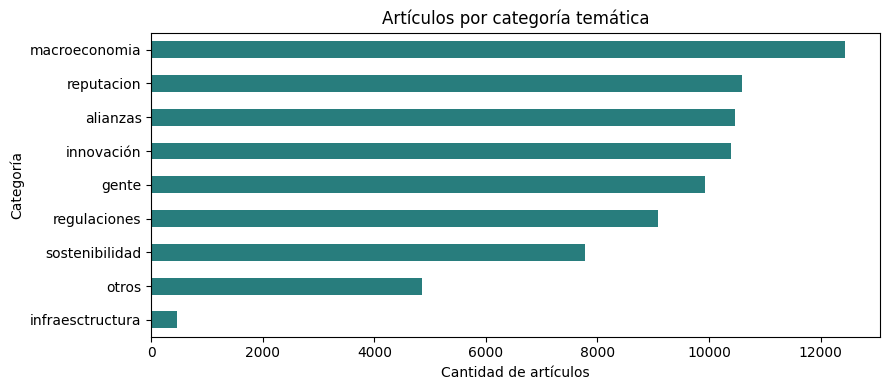

Categorías: 9
Mayor clase / menor clase: 12444 / 461
Razón de desbalance: 26.99


,count
category,
infraesctructura,461
otros,4858
sostenibilidad,7772
regulaciones,9084
gente,9934
innovación,10387
alianzas,10468
reputacion,10598
macroeconomia,12444


In [7]:
import matplotlib.pyplot as plt

class_counts = df['category'].value_counts().sort_values()
ax = class_counts.plot.barh(figsize=(9, max(4, 0.35 * len(class_counts))), color='#287d7d')
ax.set_title('Artículos por categoría temática')
ax.set_xlabel('Cantidad de artículos')
ax.set_ylabel('Categoría')
plt.tight_layout()
plt.show()

print(f'Categorías: {len(class_counts)}')
print(f'Mayor clase / menor clase: {class_counts.max()} / {class_counts.min()}')
print(f'Razón de desbalance: {class_counts.max() / class_counts.min():.2f}')
class_counts

## Longitud de los artículos

La longitud influye en el truncamiento de BERT y en el costo de memoria. Compararemos las longitudes por categoría para elegir `MAX_LEN` con evidencia, sabiendo que luego conviene comprobar cuántos textos quedan truncados.

### Longitud de palabras por categoría

El gráfico permite observar si ciertas secciones publican artículos sistemáticamente más extensos. La longitud en palabras es solo una aproximación: el tokenizador de BERT puede producir una cantidad distinta de tokens.

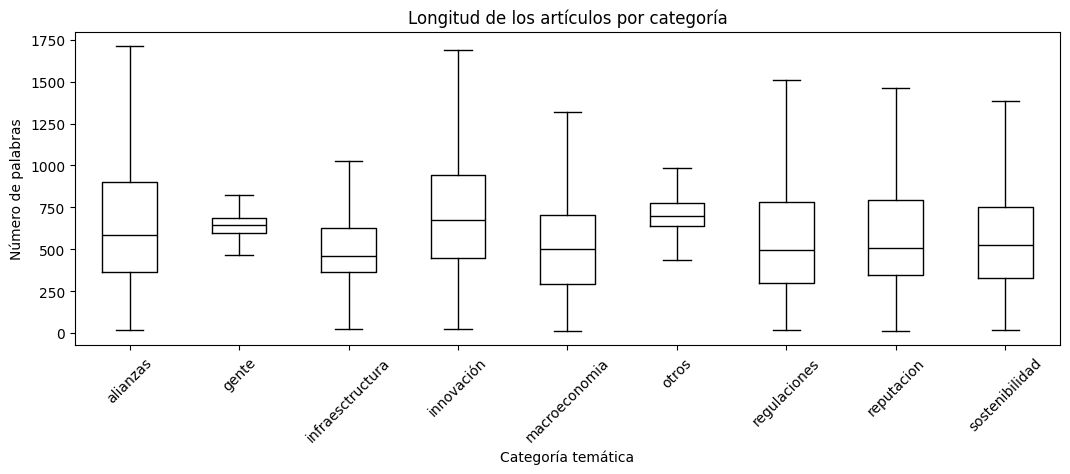

,artículos,mediana_palabras,p90_palabras
category,,,
alianzas,10468,586.0,1301.0
gente,9934,644.0,759.0
infraesctructura,461,462.0,915.0
innovación,10387,672.0,1335.0
macroeconomia,12444,504.0,847.0
otros,4858,698.0,892.0
regulaciones,9084,498.0,1109.0
reputacion,10598,510.0,1117.3
sostenibilidad,7772,525.0,1055.9


In [8]:
df['Palabras por artículo'] = df['text'].str.split().apply(len)
ax = df.boxplot('Palabras por artículo', by='category', grid=False, showfliers=False,
                color='black', figsize=(max(10, 1.2 * df['category'].nunique()), 5),
                rot=45)
plt.suptitle('')
plt.title('Longitud de los artículos por categoría')
plt.xlabel('Categoría temática')
plt.ylabel('Número de palabras')
plt.tight_layout()
plt.show()

length_summary = df.groupby('category')['Palabras por artículo'].agg(
    ['count', 'median', lambda values: values.quantile(0.9)]
)
length_summary.columns = ['artículos', 'mediana_palabras', 'p90_palabras']
length_summary

## Submuestreo del entrenamiento

Tomamos como máximo `MIN_PER_CLASS` artículos por categoría únicamente del split `train` para acotar tiempo y reducir el desbalance durante el ajuste. Los splits `valid` y `test` no se submuestrean: así la evaluación mantiene la distribución publicada por el dataset. Esta decisión limita el volumen de entrenamiento y debe considerarse al interpretar resultados.

### Decisión de muestreo

El muestreo limita las clases grandes sin replicar artificialmente ejemplos. Revisa la tabla de conteos resultante: si alguna categoría tiene pocos artículos, su resultado tendrá mayor incertidumbre aunque el resto quede balanceado.

In [9]:
MIN_PER_CLASS = 1500
train_source_df = df[df['source_split'] == 'train'].copy()
df_balanced = (
    train_source_df.groupby('category', group_keys=False)
    .apply(lambda group: group.sample(
        n=min(len(group), MIN_PER_CLASS), random_state=42
    ))
    .sample(frac=1, random_state=42)
    .reset_index(drop=True)
)
print(f'Tamaño de entrenamiento tras el submuestreo: {df_balanced.shape}')
print('\nArtículos de entrenamiento por categoría:')
print(df_balanced['category'].value_counts())
print('\nLos conjuntos valid y test conservan sus registros originales.')

Tamaño de entrenamiento tras el submuestreo: (12362, 7)

Artículos de entrenamiento por categoría:
category
innovación          1500
gente               1500
macroeconomia       1500
otros               1500
alianzas            1500
sostenibilidad      1500
regulaciones        1500
reputacion          1500
infraesctructura     362
Name: count, dtype: int64

Los conjuntos valid y test conservan sus registros originales.


## Tokenizador de BERT

Usamos `dccuchile/bert-base-spanish-wwm-cased`, preentrenado para español. Mantener emparejados el modelo y su tokenizador evita asignar IDs incompatibles. Los artículos se tokenizan sin normalización manual agresiva para conservar nombres propios, acentos y señales editoriales.

### Tokenización de texto periodístico

Se conserva el casing de BERT. La prueba rápida emplea un titular y una bajada de noticias.

In [10]:
from transformers import AutoTokenizer

model_ckpt = "dccuchile/bert-base-spanish-wwm-cased"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)

# Titular y bajada representativos del dominio periodístico.
tokens = tokenizer(
    "El gobierno anunció nuevas medidas para impulsar la inversión pública.",
    max_length=24, truncation=True, padding='max_length'
).tokens()
print(tokens)

config.json:   0%|          | 0.00/648 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/364 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/242k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/480k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/134 [00:00<?, ?B/s]

['[CLS]', 'El', 'gobierno', 'anunció', 'nuevas', 'medidas', 'para', 'impulsar', 'la', 'inversión', 'pública', '.', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']


## 🔍 Parámetros del Tokenizador

In [11]:
print(f"Tamaño del vocabulario: {tokenizer.vocab_size}")
print(f"Longitud máxima del modelo: {tokenizer.model_max_length}")
print(f"Entradas esperadas: {tokenizer.model_input_names}")

# La decisión final de MAX_LEN se contrasta con la longitud de los artículos y
# con el porcentaje de ejemplos que quedarían truncados.

Tamaño del vocabulario: 31002
Longitud máxima del modelo: 512
Entradas esperadas: ['input_ids', 'token_type_ids', 'attention_mask']


In [12]:
# Estimamos el truncamiento con una muestra reproducible de artículos.
MAX_LEN = 128
length_sample = df_balanced.sample(
    n=min(1000, len(df_balanced)), random_state=42
).copy()
sample_token_ids = tokenizer(
    length_sample['text'].tolist(),
    add_special_tokens=True,
    truncation=False,
)['input_ids']
length_sample['Tokens'] = [len(token_ids) for token_ids in sample_token_ids]

print('Cuantiles de tokens en la muestra:')
print(length_sample['Tokens'].quantile([0.5, 0.75, 0.9, 0.95, 0.99]))
print(f"Porcentaje que excede MAX_LEN={MAX_LEN}: "
      f"{(length_sample['Tokens'] > MAX_LEN).mean():.1%}")
length_sample.groupby('category')['Tokens'].median().sort_values()

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (776 > 512). Running this sequence through the model will result in indexing errors


Cuantiles de tokens en la muestra:
0.50     776.50
0.75     964.00
0.90    1316.30
0.95    1615.80
0.99    2817.84
Name: Tokens, dtype: float64
Porcentaje que excede MAX_LEN=128: 98.1%


,Tokens
category,
regulaciones,573.5
infraesctructura,618.0
reputacion,638.0
sostenibilidad,667.0
macroeconomia,691.5
alianzas,765.0
innovación,819.5
gente,832.0
otros,888.0


## Experimento 1: BERT congelado (baseline)

Se congela el encoder y se entrena únicamente la cabeza lineal de clasificación. Este baseline estima cuánto aportan las representaciones preentrenadas sin adaptación al corpus. Su ventaja esperada es el menor costo; no se asumirá que tendrá menor rendimiento antes de comparar los resultados.

## Construcción del baseline congelado

El número de salidas se obtiene de las categorías observadas. Se congela el encoder BERT para que el entrenamiento actualice solo la cabeza lineal; se verificará el número de parámetros entrenables y la forma de los logits antes de lanzar los experimentos.

In [13]:
import torch
from torchinfo import summary
from transformers import AutoModelForSequenceClassification, set_seed

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Dispositivo: {device}")

inputs_dummy = tokenizer(
    "El gobierno aprobó una nueva ley de educación pública.",
    max_length=16, truncation=True, padding='max_length', return_tensors='pt'
)
print({key: (value.shape, value.dtype) for key, value in inputs_dummy.items()})

set_seed(42)
num_labels = len(category2id)
model = AutoModelForSequenceClassification.from_pretrained(
    model_ckpt,
    num_labels=num_labels,
    id2label=id2category,
    label2id=category2id,
).to(device)

for param in model.base_model.parameters():
    param.requires_grad = False

input_sizes = [inputs_dummy['input_ids'].shape] * 3
input_types = [inputs_dummy['input_ids'].dtype] * 3
with torch.no_grad():
    print(summary(model, input_size=input_sizes, dtypes=input_types,
                  col_names=['input_size', 'output_size', 'num_params', 'trainable']))

Dispositivo: cuda
{'input_ids': (torch.Size([1, 16]), torch.int64), 'token_type_ids': (torch.Size([1, 16]), torch.int64), 'attention_mask': (torch.Size([1, 16]), torch.int64)}


pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  440MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Layer (type:depth-idx)                                  Input Shape               Output Shape              Param #                   Trainable
BertForSequenceClassification                           [1, 16]                   [1, 9]                    --                        Partial
├─BertModel: 1-1                                        [1, 16]                   [1, 768]                  --                        False
│    └─BertEmbeddings: 2-1                              --                        [1, 16, 768]              --                        False
│    │    └─Embedding: 3-1                              [1, 16]                   [1, 16, 768]              (23,809,536)              False
│    │    └─Embedding: 3-2                              [1, 16]                   [1, 16, 768]              (1,536)                   False
│    │    └─Embedding: 3-3                              [1, 16]                   [1, 16, 768]              (393,216)                 False
│    │    └─La

## Verificación de la Salida del Modelo

In [14]:
with torch.no_grad():
    inputs_dev = {key: value.to(device) for key, value in inputs_dummy.items()}
    outputs = model(**inputs_dev)

print("Forma de logits:", outputs.logits.shape)
print(f"Esperado: (1, {num_labels}) = (lote, categorías)")

Forma de logits: torch.Size([1, 9])
Esperado: (1, 9) = (lote, categorías)


## Split Train / Val / Test

### Particiones de origen

El corpus ya incluye `train`, `valid` y `test`. Usamos sus particiones para conservar la separación definida por el dataset: submuestreamos solo `train` por categoría y dejamos `valid` y `test` intactos para selección y evaluación final.

In [15]:
from datasets import Dataset as HFDataset
from datasets.dataset_dict import DatasetDict

train_df = df_balanced.copy()
val_df = df[df['source_split'] == 'valid'].copy()
test_df = df[df['source_split'] == 'test'].copy()

def to_hf_dataset(frame):
    return HFDataset.from_pandas(
        frame[['text', 'category', 'category_id']].rename(
            columns={'category_id': 'label_raw'}
        ),
        preserve_index=False,
    )

dataset_split = DatasetDict({
    'train': to_hf_dataset(train_df),
    'val': to_hf_dataset(val_df),
    'test': to_hf_dataset(test_df),
})
print(dataset_split)
print('Conteos por split y categoría:')
for split_name, split_data in dataset_split.items():
    print(f'\n{split_name}')
    print(pd.Series(split_data['category']).value_counts().sort_index())

DatasetDict({
    train: Dataset({
        features: ['text', 'category', 'label_raw'],
        num_rows: 12362
    })
    val: Dataset({
        features: ['text', 'category', 'label_raw'],
        num_rows: 12152
    })
    test: Dataset({
        features: ['text', 'category', 'label_raw'],
        num_rows: 3046
    })
})
Conteos por split y categoría:

train
alianzas            1500
gente               1500
infraesctructura     362
innovación          1500
macroeconomia       1500
otros               1500
regulaciones        1500
reputacion          1500
sostenibilidad      1500
Name: count, dtype: int64

val
alianzas            1668
gente               1619
infraesctructura      83
innovación          1661
macroeconomia       1997
otros                781
regulaciones        1421
reputacion          1690
sostenibilidad      1232
Name: count, dtype: int64

test
alianzas            408
gente               409
infraesctructura     16
innovación          432
macroeconomia       523
o

### Baseline clásico: TF-IDF y Regresión Logística

Antes de entrenar BERT, establecemos una referencia clásica sobre los mismos artículos y particiones. TF-IDF representa los textos mediante n-gramas ponderados; la regresión logística permite comprobar cuánto se logra sin un encoder Transformer.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from sklearn.pipeline import Pipeline
from time import perf_counter

classical_baseline = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=2,
        max_features=100_000,
        sublinear_tf=True,
    )),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42)),
])

start_time = perf_counter()
classical_baseline.fit(train_df['text'], train_df['category_id'])
classical_predictions = classical_baseline.predict(test_df['text'])
classical_runtime = perf_counter() - start_time

results_classical = {
    'eval_accuracy': accuracy_score(test_df['category_id'], classical_predictions),
    'eval_f1': f1_score(
        test_df['category_id'], classical_predictions, average='macro'
    ),
}
print('Resultados TF-IDF + Regresión Logística:', results_classical)
print(f'Tiempo de ajuste y predicción: {classical_runtime:.1f} s')

## Tokenización y Etiquetas

In [16]:
MAX_LEN = 128  # Contrastar después con la distribución de longitudes tokenizadas.

def preprocess_function(examples):
    """Tokeniza artículos y conserva la etiqueta numérica de su categoría."""
    encoding = tokenizer(
        examples['text'],
        max_length=MAX_LEN,
        truncation=True,
        padding='max_length'
    )
    encoding['label'] = examples['label_raw']
    return encoding

tokenized_dataset = dataset_split.map(preprocess_function, batched=True)
tokenized_dataset = tokenized_dataset.remove_columns(['text', 'category', 'label_raw'])
tokenized_dataset.set_format('torch')

print(tokenized_dataset)
print("Columnas de entrada:", tokenized_dataset['train'].column_names)

Map:   0%|          | 0/12362 [00:00<?, ? examples/s]

Map:   0%|          | 0/12152 [00:00<?, ? examples/s]

Map:   0%|          | 0/3046 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'label'],
        num_rows: 12362
    })
    val: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'label'],
        num_rows: 12152
    })
    test: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'label'],
        num_rows: 3046
    })
})
Columnas de entrada: ['input_ids', 'token_type_ids', 'attention_mask', 'label']


## Configuración del Trainer

### Configuración del entrenamiento

Definimos las métricas, los argumentos de entrenamiento y el Trainer de Hugging Face.

In [ ]:
from transformers import Trainer, TrainingArguments, set_seed
import evaluate
import numpy as np

accuracy = evaluate.load("accuracy")
f1 = evaluate.load("f1")

def compute_metrics(pred):
    """Reporta accuracy y F1 macro para reflejar rendimiento global y por clase."""
    labels = pred.label_ids
    predicted = np.argmax(pred.predictions, axis=-1)
    return {
        **accuracy.compute(predictions=predicted, references=labels),
        **f1.compute(predictions=predicted, references=labels, average='macro'),
    }

batch_size = 16 if IN_COLAB else 8
logging_steps = max(1, len(tokenized_dataset['train']) // batch_size)

training_args = TrainingArguments(
    output_dir='./bert_noticias_featurizer',
    num_train_epochs=3,
    learning_rate=2e-4,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='eval_f1',
    greater_is_better=True,
    seed=42,
    data_seed=42,
    logging_steps=logging_steps,
    report_to='none',
    fp16=torch.cuda.is_available(),
)

set_seed(42)
trainer = Trainer(
    model=model,
    args=training_args,
    compute_metrics=compute_metrics,
    train_dataset=tokenized_dataset['train'],
    eval_dataset=tokenized_dataset['val'],
    processing_class=tokenizer,
)

## Entrenamiento — Featurizer Simple

### Entrenamiento del clasificador sobre BERT (featurizer)

Solo se actualizan los parámetros de la capa clasificadora.
Con GPU en Colab, esto debería tomar pocos minutos.

In [18]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,1.796202,1.521096,0.532752,0.445712
2,1.488881,1.387790,0.563117,0.486481
3,1.404668,1.355614,0.566491,0.489994


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=2319, training_loss=1.5632452658406102, metrics={'train_runtime': 212.7222, 'train_samples_per_second': 174.34, 'train_steps_per_second': 10.902, 'total_flos': 2439587468634624.0, 'train_loss': 1.5632452658406102, 'epoch': 3.0})

## Evaluación — Featurizer Simple

In [19]:
model.eval()
results_featurizer = trainer.evaluate(tokenized_dataset['test'])
print("Resultados featurizer:", results_featurizer)

Training Loss,Validation Loss,Epoch,Accuracy,F1
1.404668,1.369832,3,0.566645,0.485489


Resultados featurizer: {'eval_loss': 1.3698318004608154, 'eval_accuracy': 0.5666447800393959, 'eval_f1': 0.48548883567669204}


## Clasificador Personalizado

Reemplazamos la capa lineal de BERT por un clasificador más profundo, manteniendo el encoder congelado.

## Clasificador personalizado

Reemplazamos la capa lineal simple de BERT por un clasificador más profundo,
manteniendo el encoder congelado (featurizer).

In [20]:
import torch.nn as nn

# Repetimos desde el checkpoint original para aislar este experimento.
set_seed(42)
model = AutoModelForSequenceClassification.from_pretrained(
    model_ckpt,
    num_labels=num_labels,
    id2label=id2category,
    label2id=category2id,
).to(device)
for param in model.base_model.parameters():
    param.requires_grad = False

hidden_size = model.config.hidden_size
classifier_custom = nn.Sequential(
    nn.Linear(hidden_size, 256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, 64),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(64, num_labels),
)
model.classifier = classifier_custom

with torch.no_grad():
    input_sizes = [inputs_dummy['input_ids'].shape] * 3
    input_types = [inputs_dummy['input_ids'].dtype] * 3
    print(summary(model, input_size=input_sizes, dtypes=input_types,
                  col_names=['input_size', 'output_size', 'num_params', 'trainable']))

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	

Layer (type:depth-idx)                                  Input Shape               Output Shape              Param #                   Trainable
BertForSequenceClassification                           [1, 16]                   [1, 9]                    --                        Partial
├─BertModel: 1-1                                        [1, 16]                   [1, 768]                  --                        False
│    └─BertEmbeddings: 2-1                              --                        [1, 16, 768]              --                        False
│    │    └─Embedding: 3-1                              [1, 16]                   [1, 16, 768]              (23,809,536)              False
│    │    └─Embedding: 3-2                              [1, 16]                   [1, 16, 768]              (1,536)                   False
│    │    └─Embedding: 3-3                              [1, 16]                   [1, 16, 768]              (393,216)                 False
│    │    └─La

## Entrenamiento — Clasificador Personalizado

In [ ]:
# Carpeta independiente para que checkpoints de experimentos no se mezclen.
training_args.output_dir = './bert_noticias_clasificador_custom'
set_seed(42)
trainer = Trainer(
    model=model,
    args=training_args,
    compute_metrics=compute_metrics,
    train_dataset=tokenized_dataset['train'],
    eval_dataset=tokenized_dataset['val'],
    processing_class=tokenizer,
)

trainer.train()
model.eval()
results_custom = trainer.evaluate(tokenized_dataset['test'])
print("Resultados del clasificador personalizado:", results_custom)

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,1.737111,1.348358,0.527156,0.437205
2,1.379856,1.231576,0.575132,0.498228
3,1.304781,1.200463,0.586241,0.510986


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Loss,Validation Loss,Epoch,Accuracy,F1
1.304781,1.203633,3,0.594222,0.513727


Resultados del clasificador personalizado: {'eval_loss': 1.2036327123641968, 'eval_accuracy': 0.5942219304005253, 'eval_f1': 0.5137272296186957}


## Experimento 3: fine-tuning completo de BERT

Se actualizan el encoder y la cabeza de clasificación con una tasa de aprendizaje menor. La hipótesis es que la adaptación al dominio periodístico puede mejorar la separación de categorías, a cambio de mayor costo y riesgo de sobreajuste. Se evaluará en el mismo test y con las mismas métricas de los otros experimentos.

> El tiempo y la memoria dependen de la GPU y del tamaño del subconjunto. Si se agotan recursos, reduce `MIN_PER_CLASS`, `MAX_LEN` o el batch size y anota el cambio para mantener transparente la comparación.

Se permite que todas las capas de BERT se adapten al conjunto de noticias. Compara este resultado con los enfoques congelados usando las mismas particiones, métricas y presupuesto de datos.

In [ ]:
set_seed(42)
model_ft = AutoModelForSequenceClassification.from_pretrained(
    model_ckpt,
    num_labels=num_labels,
    id2label=id2category,
    label2id=category2id,
).to(device)

training_args_ft = TrainingArguments(
    output_dir='./bert_noticias_finetune',
    num_train_epochs=2,
    learning_rate=2e-5,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='eval_f1',
    greater_is_better=True,
    seed=42,
    data_seed=42,
    logging_steps=logging_steps,
    report_to='none',
    fp16=torch.cuda.is_available(),
)

trainer_ft = Trainer(
    model=model_ft,
    args=training_args_ft,
    compute_metrics=compute_metrics,
    train_dataset=tokenized_dataset['train'],
    eval_dataset=tokenized_dataset['val'],
    processing_class=tokenizer,
)

trainer_ft.train()
model_ft.eval()
results_ft = trainer_ft.evaluate(tokenized_dataset['test'])
print("Resultados fine-tuning:", results_ft)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.901556,0.740394,0.757077,0.718405
2,0.549717,0.702539,0.771643,0.737403


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Loss,Validation Loss,Epoch,Accuracy,F1
0.549717,0.717678,2,0.760998,0.723692


Resultados fine-tuning: {'eval_loss': 0.7176780700683594, 'eval_accuracy': 0.7609980302035456, 'eval_f1': 0.7236920525896117}


In [ ]:
comparison = pd.DataFrame([
    {'Experimento': 'TF-IDF + Regresión Logística',
     'Accuracy': results_classical['eval_accuracy'],
     'F1 macro': results_classical['eval_f1']},
    {'Experimento': 'BERT congelado',
     'Accuracy': results_featurizer.get('eval_accuracy'),
     'F1 macro': results_featurizer.get('eval_f1')},
    {'Experimento': 'Clasificador personalizado',
     'Accuracy': results_custom.get('eval_accuracy'),
     'F1 macro': results_custom.get('eval_f1')},
    {'Experimento': 'Fine-tuning completo',
     'Accuracy': results_ft.get('eval_accuracy'),
     'F1 macro': results_ft.get('eval_f1')},
]).set_index('Experimento')

print('Comparación en el mismo conjunto de prueba:')
display(comparison.sort_values('F1 macro', ascending=False))
ax = comparison[['Accuracy', 'F1 macro']].plot.bar(
    figsize=(10, 5), ylim=(0, 1), color=['#287d7d', '#e39c37']
)
ax.set_title('Comparación de enfoques en test')
ax.set_ylabel('Puntaje')
ax.set_xlabel('')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

### Discusión comparativa

Completa este análisis después de ejecutar los tres experimentos:

- ¿Qué enfoque obtuvo mayor F1 macro y cuál fue la diferencia frente al baseline?
- ¿La conclusión coincide con accuracy? Si no, ¿qué indica sobre el rendimiento por categoría?
- ¿La ganancia del fine-tuning compensa el tiempo adicional observado?
- ¿El clasificador más profundo superó al lineal? Relaciona el resultado con su capacidad y el tamaño de entrenamiento.

Reporta los valores concretos de la tabla. No concluyas que un modelo es mejor solo por una diferencia pequeña sin considerar variabilidad, costo y limitaciones del split.

## Análisis de Predicciones

### Análisis de predicciones

Inspeccionamos las predicciones del modelo de fine-tuning y los errores cometidos.

In [24]:
predictions = trainer_ft.predict(tokenized_dataset['test'])
predicted_labels = np.argmax(predictions.predictions, axis=-1)

test_set = tokenized_dataset['test']
test_set = test_set.add_column('prediction_label', predicted_labels.tolist())
test_set = test_set.add_column(
    'prediction',
    [id2category[int(lbl)] for lbl in predicted_labels]
)

# Reconstruimos el texto original para visualización
original_texts = dataset_split['test']['text']
test_set = test_set.add_column('text_original', original_texts)
test_set = test_set.add_column(
    'category_true',
    [id2category[int(lbl)] for lbl in test_set['label']]
)

columns = ['text_original', 'label', 'prediction_label', 'category_true', 'prediction']
test_set.set_format('pandas', columns=columns)
df_pred = test_set.to_pandas()[columns]
df_pred.head(15)

,text_original,label,prediction_label,category_true,prediction
0,La incineradora de L’Alcora fue autorizada sin...,8,8,sostenibilidad,sostenibilidad
1,Compañía alemana invertirá US$700 millones par...,4,2,macroeconomia,infraesctructura
2,Políticas para captar el capital privado\n\nJa...,3,3,innovación,innovación
3,Futuro prometedor y amenazas preocupantes para...,4,4,macroeconomia,macroeconomia
4,El grupo empresarial de la Once cierra 2008 co...,7,7,reputacion,reputacion
5,Renfe se abre a renovar la imagen de la marca ...,3,3,innovación,innovación
6,El Consejo de Ministros aprueba la prórroga de...,6,6,regulaciones,regulaciones
7,¿Transformación digital? Esto no ha hecho más ...,3,3,innovación,innovación
8,Fedesarrollo estima que la reforma tributaria ...,4,4,macroeconomia,macroeconomia
9,Dólar abre estable gracias a mejores precios d...,4,4,macroeconomia,macroeconomia


## Análisis de errores y rendimiento por categoría

La métrica global no muestra qué temas se confunden. Revisaremos precisión, recall y F1 por categoría, la matriz de confusión normalizada y ejemplos mal clasificados. Para cada patrón, inspecciona si el texto es ambiguo, si comparte vocabulario con otra sección o si puede haber ruido en la etiqueta; evita atribuir causas sin revisar los artículos.

                  precision    recall  f1-score   support

        alianzas      0.770     0.681     0.723       408
           gente      0.955     0.936     0.946       409
infraesctructura      0.233     0.875     0.368        16
      innovación      0.656     0.597     0.625       432
   macroeconomia      0.865     0.872     0.869       523
           otros      0.782     0.944     0.855       197
    regulaciones      0.798     0.753     0.775       340
      reputacion      0.585     0.632     0.608       413
  sostenibilidad      0.756     0.734     0.745       308

        accuracy                          0.761      3046
       macro avg      0.711     0.781     0.724      3046
    weighted avg      0.770     0.761     0.763      3046



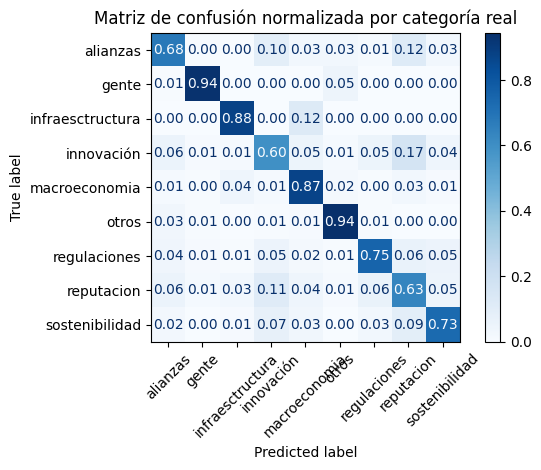

Errores: 728 de 3046 artículos


,category_true,prediction,text_original
1,macroeconomia,infraesctructura,Compañía alemana invertirá US$700 millones par...
11,sostenibilidad,reputacion,Un miembro de la tribu de Ribera para controla...
13,innovación,alianzas,“Rodolfo Hernández es un muy buen producto y n...
14,alianzas,reputacion,Utilidad neta del Grupo Energía Bogotá a marzo...
21,sostenibilidad,reputacion,10 pueblos de Colombia para viajar barato en s...
32,reputacion,regulaciones,La polémica ley antigay de Florida destapa un ...
33,sostenibilidad,alianzas,Envase de Tetra Pak: ¿Por qué y cómo reciclarl...
35,regulaciones,sostenibilidad,"Aborto, armas o cambio climático: las sentenci..."
42,innovación,reputacion,"TGI (filial GEB) elevó ingresos, pero redujo g..."
47,innovación,macroeconomia,IDEA presentó balance exitoso en rendición de ...


In [25]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

true_labels = df_pred['label'].to_numpy()
predicted_labels = df_pred['prediction_label'].to_numpy()
label_ids = list(id2category.keys())
label_names = [id2category[label_id] for label_id in label_ids]

print(classification_report(
    true_labels,
    predicted_labels,
    labels=label_ids,
    target_names=label_names,
    zero_division=0,
    digits=3,
))

ConfusionMatrixDisplay.from_predictions(
    true_labels,
    predicted_labels,
    labels=label_ids,
    display_labels=label_names,
    normalize='true',
    xticks_rotation=45,
    cmap='Blues',
    values_format='.2f',
)
plt.title('Matriz de confusión normalizada por categoría real')
plt.tight_layout()
plt.show()

errors = df_pred[df_pred['label'] != df_pred['prediction_label']]
print(f'Errores: {len(errors)} de {len(df_pred)} artículos')
errors[['category_true', 'prediction', 'text_original']].head(10)

## Conclusiones

Completa estas conclusiones después de ejecutar el notebook. Incluye valores concretos de la tabla y del reporte por categoría:

- **Respuesta a la pregunta:** compara el F1 macro y accuracy de TF-IDF con los tres enfoques BERT; cuantifica las diferencias.
- **Hipótesis:** indica si el fine-tuning mejora frente a BERT congelado y al baseline clásico, y si la ganancia justifica el costo de cómputo.
- **Categorías difíciles:** identifica las clases con menor F1 y las confusiones principales; revisa ejemplos antes de proponer causas.
- **Costo y decisión:** compara los tiempos observados y el desempeño para recomendar un enfoque según los recursos disponibles.
- **Limitaciones:** considera el submuestreo solo en `train`, el posible ruido de etiquetas, los duplicados eliminados y que las particiones publicadas no garantizan generalización a otros medios o periodos.
- **Siguiente experimento:** propone una mejora medible, por ejemplo variar `MAX_LEN`, ajustar la regularización del baseline, comparar tasas de aprendizaje o evaluar noticias de otro periodo.

No concluyas que un modelo es mejor solo por una diferencia pequeña. Sustenta la conclusión con los resultados obtenidos en este corpus.